## <font color= 'green'  align="center"> **MODELISATION DE L'ABSENSE DE POURBOIRE CHEZ LES CHAUFFEURS DE TAXI DE NEW YORK** </font>

![Imgur](https://media.lematin.ch/4/image/2023/11/10/51338278-59cd-4559-af66-8efbac423112.jpeg?auto=format%2Ccompress%2Cenhance&fit=max&w=1200&h=1200&rect=0%2C0%2C1024%2C683&s=7864704c0ca9395afa830274aeb70f2e)




# Contexte
Le projet porte sur la modélisation de la **générosité des clients** des taxis new-yorkais à partir de données de trajets.  
Il sera question pour nous dans ce projet de construire un modèle capable de prédire si un client **est_généreux** ou non, en se basant sur des variables telles que la durée du trajet, la distance, ou encore l’heure de la course...

Il aurait pu être question  pour nous de prédire si un client laissera un pourboire ou non, mais étant donné la problématique y relative, on se contentera de classifier un client de généreux ou non à partir de ses données

---

## Objectif
Prédire si un client sera classé **est_généreux** (donnera un pourboire supérieur ou égale à 20% du montant de la course) ou non, à partir des données de trajets de taxi à New York.

---

## Structure du Projet

### I. Chargement du Dataset

- Importation des bibliothèques nécessaires 
- Importation et fusion des deux parties du jeu de données 
- Création de la **target** binaire (ex: `Generous = tip_amount > 20%Total_amount`)

---

### II. Séparation du Dataset
- Séparation en deux sous-ensembles :
  - `Train set`
  - `Test set`
- (Utilisation de `train_test_split` de `sklearn`)

---

### III. Analyse exploratoire (EDA)
- Visualisation générale du dataset
- Analyse de la répartition de la target
- Analyse bivariée entre la target et les certaines features
- Analyse des distributions 

---

### IV. Prétraitement
- Nettoyage des données (valeurs manquantes, types, outliers)
- Feature Engineering :
  - Création de variables à partir de la date/heure
- Encodage des variables catégorielles
- Standardisation / Normalisation si nécessaire

---

### V. Sélection et évaluation des modèles (Validation croisée)
- Mise en place d'une **Grid Search** avec **Validation Croisée**
- Entraînement et comparaison de plusieurs modèles :
  - KNN
  - Random Forest
  - Gradient Boosting
  - etc.
- Sélection des meilleurs hyperparamètres

---

### VI. Ré-entraînement final du modèle
- Entraînement sur **tout le Train Set** avec les meilleurs hyperparamètres

---

### VII. Évaluation sur le Test Set
- Prédictions finales
- Mesures de performance :
  - Accuracy, Precision, Recall, F1-Score
  - Matrice de confusion
  - ROC-AUC

---

### VIII. Conclusion & pistes d'amélioration
- Interprétation des résultats
- Analyse des erreurs
- Possibilités d'amélioration (plus de données, autres features, tuning...)



# <font color='red'> I. Chargement du Dataset </font>

In [23]:
# Manipulation de données
import pandas as pd
import numpy as np
import copy

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Modèles
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Pour le feature engineering (extraction de date, heure, etc.)
from datetime import datetime

In [25]:
## **Chargement et fusion des deux parties du dataset**
d1=pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
d2=pd.read_csv('nyc_preds_means.csv')

data=pd.concat([d1,d2], axis=1)
data=pd.DataFrame(data)
data

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.00,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.00,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.00,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.00,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.00,0.3,17.80,14.616667,4.435000,15.845642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22694,14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,N,48,186,...,4.0,1.0,0.5,0.00,0.00,0.3,5.80,8.594643,1.098214,7.799138
22695,66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,N,132,164,...,52.0,0.0,0.5,14.64,5.76,0.3,73.20,59.560417,18.757500,52.000000
22696,74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,N,107,234,...,4.5,0.0,0.5,0.00,0.00,0.3,5.30,6.609091,0.684242,6.130896
22697,60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,N,68,144,...,10.5,0.0,0.5,1.70,0.00,0.3,13.00,16.650000,2.077500,11.707049


In [27]:
#Création d'une copy du jeu de données
df=copy.deepcopy(data)

#Traduction de ses colonnes en français
# Dictionnaire de traduction 
column_translation = {
    "Unnamed: 0": "ID",
    "VendorID": "ID_ven",
    "tpep_pickup_datetime": "dt_départ",
    "tpep_dropoff_datetime": "dt_arrivée",
    "passenger_count": "nb_pass",
    "trip_distance": "dist_trajet",
    "RatecodeID": "code_tarif",
    "store_and_fwd_flag": "données_différé",
    "PULocationID": "ID_dep",
    "DOLocationID": "ID_arr",
    "payment_type": "type_paie",
    "fare_amount": "montant_course",
    "extra": "supplément",
    "mta_tax": "taxe_mta",
    "tip_amount": "pourboire",
    "tolls_amount": "péages",
    "improvement_surcharge": "suppl_amélioration",
    "total_amount": "montant_total",
    "mean_duration": "duree_moy",
    "mean_distance": "dist_moy",
    "predicted_fare": "tarif_prédit"
}

# Application du renommage
df.rename(columns=column_translation, inplace=True)

#Vérifie le résultat
print(df.columns)

Index(['ID', 'ID_ven', 'dt_départ', 'dt_arrivée', 'nb_pass', 'dist_trajet',
       'code_tarif', 'données_différé', 'ID_dep', 'ID_arr', 'type_paie',
       'montant_course', 'supplément', 'taxe_mta', 'pourboire', 'péages',
       'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy',
       'tarif_prédit'],
      dtype='object')


In [29]:
#Création de la colonne 'client_genereux' qui est notre target
df['client_genereux'] = (df['pourboire'] >= 0.2 * df['montant_total']).astype(int)

# Suppression des colonnes impliquées dans la target pour éviter que le modèle triche

df = df.drop(columns=['montant_total'])
df.head()

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,ID_dep,ID_arr,...,montant_course,supplément,taxe_mta,pourboire,péages,suppl_amélioration,duree_moy,dist_moy,tarif_prédit,client_genereux
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.0,0.3,22.847222,3.521667,16.434245,0
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.0,0.3,24.470370,3.108889,16.052218,0
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.0,0.3,7.250000,0.881429,7.053706,0
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.0,0.3,30.250000,3.700000,18.731650,1
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.0,0.3,14.616667,4.435000,15.845642,0


# <font color="red"> II. Séparation du Dataset </font>

In [8]:
# Définir X (features) et y (target)
X = df.drop(columns=['client_genereux'])
y = df['client_genereux']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # pour reproductibilité
    stratify=y           # garde la même proportion de classes dans y car ma target est déséquilibrée
)

# <font color='red'>III. Analyse exploratoire (EDA) </font>

In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18159 entries, 3996 to 6403
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  18159 non-null  int64  
 1   ID_ven              18159 non-null  int64  
 2   dt_départ           18159 non-null  object 
 3   dt_arrivée          18159 non-null  object 
 4   nb_pass             18159 non-null  int64  
 5   dist_trajet         18159 non-null  float64
 6   code_tarif          18159 non-null  int64  
 7   données_différé     18159 non-null  object 
 8   ID_dep              18159 non-null  int64  
 9   ID_arr              18159 non-null  int64  
 10  type_paie           18159 non-null  int64  
 11  montant_course      18159 non-null  float64
 12  supplément          18159 non-null  float64
 13  taxe_mta            18159 non-null  float64
 14  pourboire           18159 non-null  float64
 15  péages              18159 non-null  float64
 16  suppl_a

In [11]:
X_train.describe()

,ID,ID_ven,nb_pass,dist_trajet,code_tarif,ID_dep,ID_arr,type_paie,montant_course,supplément,taxe_mta,pourboire,péages,suppl_amélioration,duree_moy,dist_moy,tarif_prédit
count,1.815900e+04,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,5.702022e+07,1.555427,1.641004,2.920685,1.046093,162.510160,161.758357,1.339942,13.063972,0.332012,0.497247,1.840531,0.312777,0.299537,14.445721,2.916524,12.983049
std,3.270325e+07,0.496932,1.283365,3.674118,0.782576,66.777003,70.184640,0.498513,13.796419,0.463641,0.041227,2.903717,1.405049,0.016353,10.108616,3.574283,9.741269
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,0.000000,0.000000,2.934494
25%,2.893806e+07,1.000000,1.000000,0.990000,1.000000,114.000000,113.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.030952,1.006667,7.381905
50%,5.681397e+07,2.000000,1.000000,1.600000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.556667,1.620000,9.560140
75%,8.560409e+07,2.000000,2.000000,3.080000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.316667,3.114286,13.921530
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,88.783333,33.920000,89.171050


In [86]:
X_train.dtypes.value_counts()

float64    9
int64      7
object     3
Name: count, dtype: int64

<Axes: >

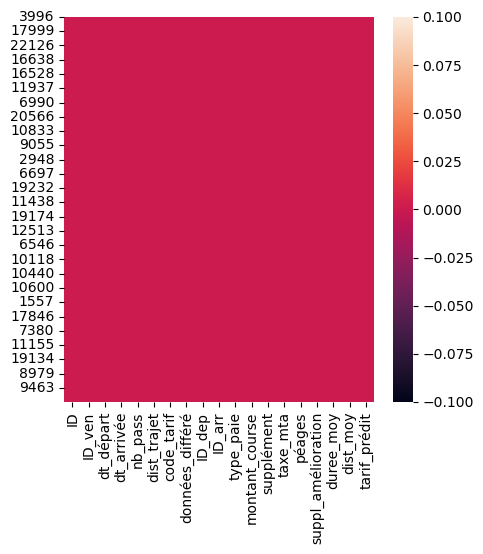

In [91]:
#Visualisation des valeurs manquantes en heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(X_train.isna())

 **Interpretation**:
Le dataset est complet et ne contient aucune valeur manquante

In [120]:
# Analyse des variables catégorielles:
for col in X_train.select_dtypes(include=['object']):
    print(f'{col:-<30} {X_train[col].unique()}')

dt_départ--------------------- ['05/27/2017 1:09:31 PM' '01/24/2017 7:45:04 AM' '12/28/2017 1:43:03 PM'
 ... '03/26/2017 1:52:11 AM' '12/04/2017 12:44:58 PM'
 '11/09/2017 9:36:38 PM']
dt_arrivée-------------------- ['05/27/2017 1:44:25 PM' '01/24/2017 7:53:58 AM' '12/28/2017 2:06:37 PM'
 ... '03/26/2017 2:07:27 AM' '12/04/2017 1:29:18 PM'
 '11/09/2017 9:48:28 PM']
données_différé--------------- ['N' 'Y']
